# Capstone Project Dicoding: ArthaWise-Personal Finance Tracker
- **Dataset** : https://www.kaggle.com/datasets/ugisugiman/data-finance
- **Anggota DS-1** : Muhammad Rafi Reshad Fitrahansyah - CDCC200D6Y2234
- **Anggota DS-2** : Erna Listi Anggraeni - CDCC200D6X2239

---

## Tahapan
1. Problem Discovery & Business Question
2. Gathering Dataset
3. Assessing Data Quality
4. Data Wrangling & Cleaning
5. Exploratory Data Analysis
6. Feature Engineering


---
# Problem Discovery & Business Question

## Problem Discovery

Pengelolaan keuangan pribadi merupakan tantangan nyata bagi banyak individu, khususnya generasi muda yang memiliki berbagai sumber pemasukan dan pengeluaran yang beragam. Dataset *Personal Finance Tracker* ini merepresentasikan catatan transaksi keuangan harian selama 6 bulan (Juli–Desember 2025) yang mencakup berbagai kategori pengeluaran seperti Makan & Minum, Belanja, Tagihan, dan Hiburan, serta pemasukan dari Gaji dan Goals (Investasi, Tabungan, Cashback).

Permasalahan utama yang diangkat:
- Individu sering kesulitan memantau distribusi pengeluaran mereka per kategori setiap bulannya
- Tidak ada gambaran jelas mengenai keseimbangan antara pemasukan dan pengeluaran secara temporal
- Belum ada analisis berbasis waktu yang dapat membantu perencanaan dan penghematan keuangan ke depan
- Rasio pengeluaran terhadap pemasukan tidak terpantau, sehingga risiko defisit sulit dideteksi lebih awal

Analisis ini bertujuan menjawab pertanyaan-pertanyaan bisnis untuk menghasilkan insight actionable bagi pengguna website pengelolaan keuangan harian.

---

## Business Questions

### 1. Cash Flow Analysis
**"Berapa persen perubahan net cash flow (pemasukan – pengeluaran) dari bulan Juli ke Desember 2025, dan pada bulan mana terjadi net cash flow terendah?"**

---

### 2. Spending Pattern per Category
**"Kategori pengeluaran apa yang menyumbang proporsi terbesar dari total pengeluaran selama periode Juli–Desember 2025, dan berapa rata-rata pengeluarannya per bulan?"**

---

### 3. Temporal / Seasonal Behavior
**"Berapa persen perbedaan rata-rata pengeluaran antara hari kerja (weekday) dan akhir pekan (weekend) selama periode Juli–Desember 2025?"**

---

### 4. Income Stability Analysis
**"Berapa selisih antara pemasukan tertinggi dan terendah per bulan selama Juli–Desember 2025, dan pada bulan mana pemasukan paling rendah?"**

---

### 5. Metode Pembayaran
**"Metode pembayaran (Account) apa yang paling sering digunakan untuk transaksi pengeluaran selama Juli–Desember 2025, dan berapa rata-rata nilai transaksinya per metode?"**

---

### 6. High-Impact Transactions
**"Pada hari apa dalam seminggu total pengeluaran paling tinggi selama Juli–Desember 2025, dan berapa selisihnya dengan hari pengeluaran terendah?"**


# Install Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

---
# Data Wragling

---
# Gathering Dataset

Dataset diperoleh dari pencatatan transaksi keuangan pribadi selama 6 bulan (Juli–Desember 2025). Dataset ini berisi 1.200 baris transaksi harian dengan 6 kolom: `Date`, `Title`, `Amount`, `Type`, `Category`, dan `Account`.


In [ ]:
df = pd.read_csv('Data_Finance_6_Bulan.csv')

print(f"Shape dataset : {df.shape}")
print(f"Kolom         : {list(df.columns)}")
df.head()


Shape dataset : (1200, 6)
Kolom         : ['Date', 'Title', 'Amount', 'Type', 'Category', 'Account']


,Date,Title,Amount,Type,Category,Account
0,2025-07-01,Parkir,15907.28,EXPENSE,Tagihan,Gopay
1,2025-07-01,Iuran Bulanan,12793.08,EXPENSE,Tagihan,BCA
2,2025-07-01,Lain-lain,695.24,EXPENSE,Uncategorized,Gopay
3,2025-07-01,Streaming,13464.10,EXPENSE,Hiburan,Dompet Tunai
4,2025-07-01,Warung Nasi,17475.95,EXPENSE,Makan & Minum,Dompet Tunai


---
# Assessing Data Quality

Pengecekan kualitas data meliputi:
1. Missing values
2. Tipe data
3. Duplikat
4. Outlier
5. Cek kategori unik kolom `Category`


In [ ]:
# 1. Cek Missing Values
print("=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


=== MISSING VALUES ===
Date        0
Title       0
Amount      0
Type        0
Category    0
Account     0
dtype: int64

Total missing values: 0


In [ ]:
# 2. Cek Tipe Data
print("=== TIPE DATA ===")
df.info()


=== TIPE DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1200 non-null   object 
 1   Title     1200 non-null   object 
 2   Amount    1200 non-null   float64
 3   Type      1200 non-null   object 
 4   Category  1200 non-null   object 
 5   Account   1200 non-null   object 
dtypes: float64(1), object(5)
memory usage: 56.4+ KB


In [ ]:
# 3. Cek Duplikat
print("=== DUPLIKAT ===")
n_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_duplikat}")


=== DUPLIKAT ===
Jumlah baris duplikat: 0


In [ ]:
# 4. Cek Outlier
print("=== OUTLIER ===")
numerical_cols = df.select_dtypes(include=np.number).columns
outliers_found = {}

for col in numerical_cols:
    data = df[col]
    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    minimum, maximum = q25 - cut_off, q75 + cut_off
    col_outliers = df[(df[col] < minimum) | (df[col] > maximum)]
    if not col_outliers.empty:
        outliers_found[col] = col_outliers.shape[0]
        print(f"- {col}: {col_outliers.shape[0]} outliers")

if not outliers_found:
    print("Tidak ada outlier signifikan yang terdeteksi.")


=== OUTLIER ===
- Amount: 109 outliers


### Keputusan Penanganan Outlier

Outlier ditemukan pada kolom `Amount`. Namun, tim memutuskan untuk **tidak menghapus outlier** dengan pertimbangan berikut:

- Nilai Amount yang besar (seperti gaji bulanan, investasi, tabungan) adalah transaksi yang **valid dan wajar** secara finansial
- Menghapus outlier pada data keuangan justru akan **menghilangkan informasi penting** mengenai pemasukan dan pengeluaran besar



# Data Cleaning

Berdasarkan hasil assessing, tahap cleaning yang dilakukan:
1. Konversi tipe data kolom `Date` dari string ke datetime
2. Menghapus baris dengan kategori `Uncategorized` karena tidak memberikan informasi yang bermakna untuk analisis


In [ ]:
# 1. Konversi tipe data Date
df['Date'] = pd.to_datetime(df['Date'])
print(f"Tipe data Date setelah konversi: {df['Date'].dtype}")


Tipe data Date setelah konversi: datetime64[ns]


In [ ]:
# 2. Hapus baris dengan kategori Uncategorized
df = df[df['Category'] != 'Uncategorized'].reset_index(drop=True)
print(f"Kategori unik setelah penghapusan:")
print(df['Category'].unique())


Kategori unik setelah penghapusan:
['Tagihan' 'Hiburan' 'Makan & Minum' 'Belanja' 'Gaji' 'Goals']


In [ ]:
# Verifikasi hasil cleaning
print("=== HASIL AKHIR CLEANING ===")
print(f"Total rows     : {len(df)}")
print(f"Missing values : {df.isna().sum().sum()}")
print(f"Duplikat       : {df.duplicated().sum()}")
print(f"\nDistribusi Kategori:")
print(df['Category'].value_counts())
print(f"\nDistribusi Type:")
print(df['Type'].value_counts())
df.head()


=== HASIL AKHIR CLEANING ===
Total rows     : 968
Missing values : 0
Duplikat       : 0

Distribusi Kategori:
Category
Makan & Minum    232
Tagihan          219
Hiburan          199
Belanja          198
Goals             68
Gaji              52
Name: count, dtype: int64

Distribusi Type:
Type
EXPENSE    848
INCOME     120
Name: count, dtype: int64


,Date,Title,Amount,Type,Category,Account
0,2025-07-01,Parkir,15907.28,EXPENSE,Tagihan,Gopay
1,2025-07-01,Iuran Bulanan,12793.08,EXPENSE,Tagihan,BCA
2,2025-07-01,Streaming,13464.10,EXPENSE,Hiburan,Dompet Tunai
3,2025-07-01,Warung Nasi,17475.95,EXPENSE,Makan & Minum,Dompet Tunai
4,2025-07-02,Internet,11967.09,EXPENSE,Tagihan,Gopay



# Exploratory Data Analysis (EDA)


In [ ]:
# Ekstrak fitur waktu untuk analisis
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day

# Pisahkan expense dan income
expenses_df = df[df['Type'] == 'EXPENSE'].copy()
income_df   = df[df['Type'] == 'INCOME'].copy()

month_names = {7:'Juli', 8:'Agustus', 9:'September',
               10:'Oktober', 11:'November', 12:'Desember'}

print(f"Total transaksi pengeluaran : {len(expenses_df)}")
print(f"Total transaksi pemasukan   : {len(income_df)}")


Total transaksi pengeluaran : 848
Total transaksi pemasukan   : 120


In [ ]:
### Explore Cash Flow Bulanan

monthly_cf = df.groupby(['Year', 'Month', 'Type'])['Amount'].sum().unstack(fill_value=0)
monthly_cf.columns.name = None
for col in ['EXPENSE', 'INCOME']:
    if col not in monthly_cf.columns:
        monthly_cf[col] = 0
monthly_cf['Net_Cash_Flow'] = monthly_cf['INCOME'] - monthly_cf['EXPENSE']
monthly_cf = monthly_cf.reset_index()
monthly_cf['Label'] = monthly_cf['Month'].map(month_names)
monthly_cf[['Label', 'INCOME', 'EXPENSE', 'Net_Cash_Flow']]


,Label,INCOME,EXPENSE,Net_Cash_Flow
0,Juli,2823645.0,1349633.43,1474011.57
1,Agustus,2805109.0,1421827.40,1383281.60
2,September,2512525.0,1389116.65,1123408.35
3,Oktober,2014120.0,983943.83,1030176.17
4,November,2428896.0,970526.40,1458369.60
5,Desember,2150783.0,1159868.43,990914.57


**Insight:**
- Net cash flow bulanan secara umum menunjukkan surplus, artinya pemasukan lebih besar dari pengeluaran setiap bulannya. Namun terdapat variasi antar bulan yang perlu dicermati lebih lanjut pada tahap ExDA.


In [ ]:
### Explore Pengeluaran per Kategori

expenses_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)


,Amount
Category,
Makan & Minum,2063287.96
Tagihan,1856494.83
Hiburan,1723711.41
Belanja,1631421.94


**Insight:**
- Terlihat bahwa kategori makan dan minum memiliki nilai paling tinggi. Kategori dengan nilai tertinggi berpotensi menjadi fokus utama dalam penghematan anggaran.


In [ ]:
### Explore Pengeluaran Weekday vs Weekend

exp_copy = expenses_df.copy()
exp_copy['DayOfWeek'] = exp_copy['Date'].dt.dayofweek
exp_copy['IsWeekend'] = exp_copy['DayOfWeek'].isin([5, 6])
exp_copy.groupby('IsWeekend')['Amount'].mean().rename(index={False: 'Weekday', True: 'Weekend'})


,Amount
IsWeekend,
Weekday,8429.444245
Weekend,9008.199589


**Insight:**
- Pengeluaran pada hari Weekend lebih tinggi dibandingkan pada Weekday.


In [ ]:
### Explore Pemasukan per Bulan

monthly_income = income_df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly_income['Label'] = monthly_income['Month'].map(month_names)
monthly_income[['Label', 'Amount']]


,Label,Amount
0,Juli,2823645.0
1,Agustus,2805109.0
2,September,2512525.0
3,Oktober,2014120.0
4,November,2428896.0
5,Desember,2150783.0


**Insight:**
- Pemasukan bulanan tidak sepenuhnya konstan terdapat variasi antar bulan yang mencerminkan fluktuasi sumber pemasukan seperti bonus atau pendapatan tambahan di bulan tertentu.


In [ ]:
### Explore Metode Pembayaran
expenses_df.groupby('Account')['Amount'].agg(['count', 'mean', 'sum']).sort_values('count', ascending=False)


,count,mean,sum
Account,,,
Gopay,289,8773.745813,2535612.54
BCA,287,8380.813345,2405293.43
Dompet Tunai,272,8580.919743,2334010.17


**Insight:**
- Gopay menjadi metode pembayaran dengan frekuensi tertinggi (289 kali) dan total volume terbesar mencapai Rp2.535.612,54. Secara keseluruhan, aktivitas transaksi tersebar cukup merata di ketiga metode pembayaran (Gopay, BCA, dan Dompet Tunai).


In [ ]:
### Explore Pengeluaran per Hari dalam Seminggu

day_names_map = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}
exp_dow = expenses_df.copy()
exp_dow['DayOfWeek'] = exp_dow['Date'].dt.dayofweek
exp_dow['DayName']   = exp_dow['DayOfWeek'].map(day_names_map)
exp_dow.groupby('DayName')['Amount'].sum().reindex(day_names_map.values())


,Amount
DayName,
Senin,1005630.06
Selasa,900081.23
Rabu,1277947.09
Kamis,1089728.13
Jumat,1028733.92
Sabtu,1111764.74
Minggu,861030.97


**Insight:**
- Pengeluaran mingguan cenderung memuncak di tengah minggu, tepatnya pada hari Rabu, sebelum kembali melonjak di akhir pekan pada hari Sabtu. Sebaliknya, hari Minggu menjadi momen dengan tingkat pengeluaran paling rendah dan paling efisien. Pola ini menunjukkan adanya kecenderungan aktivitas belanja atau transaksi rutin yang terpusat di hari kerja tertentu serta hari libur, sementara awal pekan berjalan lebih stabil.



# Explanatory Data Analysis (ExDA)


## Question 1

**"Berapa persen perubahan net cash flow dari bulan Juli ke Desember 2025, dan pada bulan mana terjadi net cash flow terendah?"**


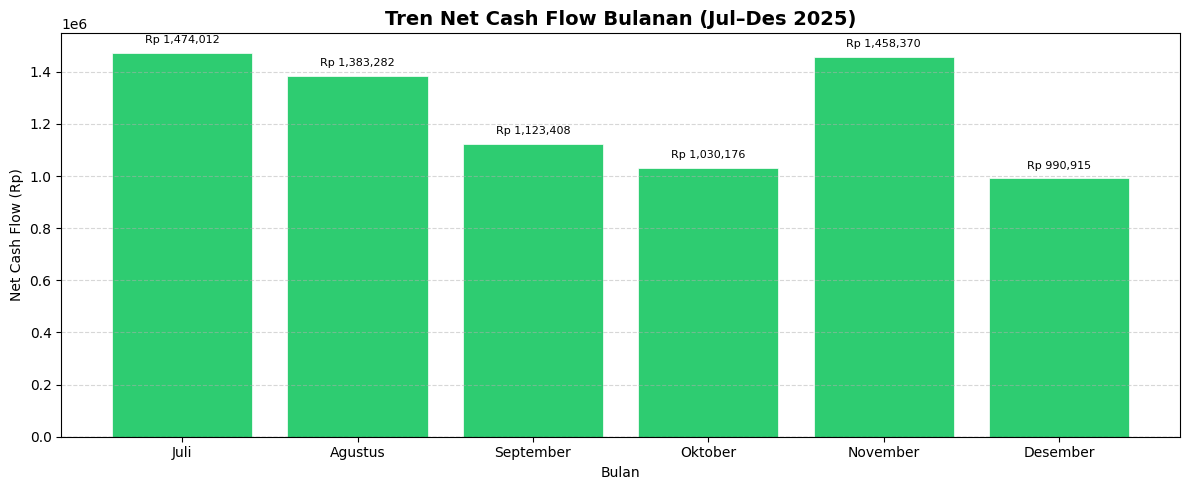

In [ ]:
# Hitung monthly income dan expense
monthly_cf = df.groupby(['Year', 'Month', 'Type'])['Amount'].sum().unstack(fill_value=0)
monthly_cf.columns.name = None

for col in ['EXPENSE', 'INCOME']:
    if col not in monthly_cf.columns:
        monthly_cf[col] = 0

monthly_cf['Net_Cash_Flow'] = monthly_cf['INCOME'] - monthly_cf['EXPENSE']
monthly_cf = monthly_cf.reset_index()
monthly_cf['Label'] = monthly_cf['Month'].map(month_names)

# Visualisasi
plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in monthly_cf['Net_Cash_Flow']]
bars = plt.bar(monthly_cf['Label'], monthly_cf['Net_Cash_Flow'],
               color=colors, edgecolor='white', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Tren Net Cash Flow Bulanan (Jul–Des 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Net Cash Flow (Rp)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, monthly_cf['Net_Cash_Flow']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30000,
             f'Rp {val:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
first_ncf = monthly_cf.iloc[0]['Net_Cash_Flow']
last_ncf  = monthly_cf.iloc[-1]['Net_Cash_Flow']
pct_change = ((last_ncf - first_ncf) / abs(first_ncf)) * 100

worst_month = monthly_cf.loc[monthly_cf['Net_Cash_Flow'].idxmin()]
avg_ncf     = monthly_cf['Net_Cash_Flow'].mean()

print(f"Net Cash Flow Juli 2025        : Rp {first_ncf:,.2f}")
print(f"Net Cash Flow Desember 2025    : Rp {last_ncf:,.2f}")
print(f"Perubahan (Jul → Des)          : {pct_change:+.2f}%")
print()
print(f"Rata-rata Net Cash Flow bulanan: Rp {avg_ncf:,.2f} (Surplus)")
print(f"Bulan dengan NCF terendah      : {worst_month['Label']} 2025")
print(f"Nilai NCF terendah             : Rp {worst_month['Net_Cash_Flow']:,.2f}")


Net Cash Flow Juli 2025        : Rp 1,474,011.57
Net Cash Flow Desember 2025    : Rp 990,914.57
Perubahan (Jul → Des)          : -32.77%

Rata-rata Net Cash Flow bulanan: Rp 1,243,360.31 (Surplus)
Bulan dengan NCF terendah      : Desember 2025
Nilai NCF terendah             : Rp 990,914.57


**Insight**

Kondisi keuangan secara umum sehat dengan rata-rata surplus bulanan sebesar Rp1,24 juta. Namun, terdapat tren penurunan Net Cash Flow yang signifikan sebesar -32,77% menuju akhir tahun, dengan titik terendah terjadi pada Desember 2025 (Rp990.914,57).
Perlu dilakukan evaluasi mendalam pada pengeluaran bulan Desember. Siapkan dana cadangan khusus (sinking fund) untuk akhir tahun sejak pertengahan tahun agar surplus NCF di bulan Desember mendatang tidak merosot tajam.

**Rekomendasi**

Pengguna disarankan untuk melakukan evaluasi terhadap pengeluaran pada bulan-bulan akhir tahun karena cenderung mengalami peningkatan dibandingkan bulan lainnya. Selain itu, pengguna dapat menerapkan strategi sinking fund atau dana cadangan sejak pertengahan tahun untuk mengantisipasi kebutuhan musiman seperti liburan, hadiah, maupun pengeluaran tak terduga di akhir tahun sehingga kondisi cash flow tetap stabil.

## Question 2

**"Kategori pengeluaran apa yang menyumbang proporsi terbesar dari total pengeluaran Juli–Desember 2025, dan berapa rata-rata bulanannya?"**


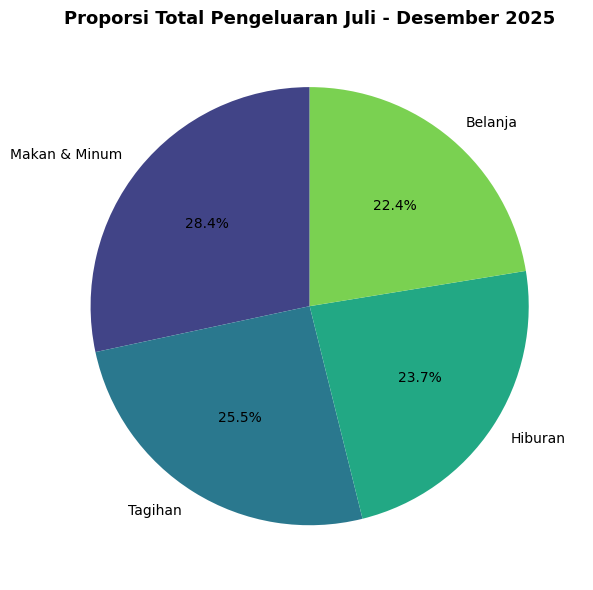

In [ ]:
expense_by_cat = expenses_df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, figsize=(16, 6))
# Pie chart
ax.pie(expense_by_cat.values, labels=expense_by_cat.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', len(expense_by_cat)))
ax.set_title('Proporsi Total Pengeluaran Juli - Desember 2025', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

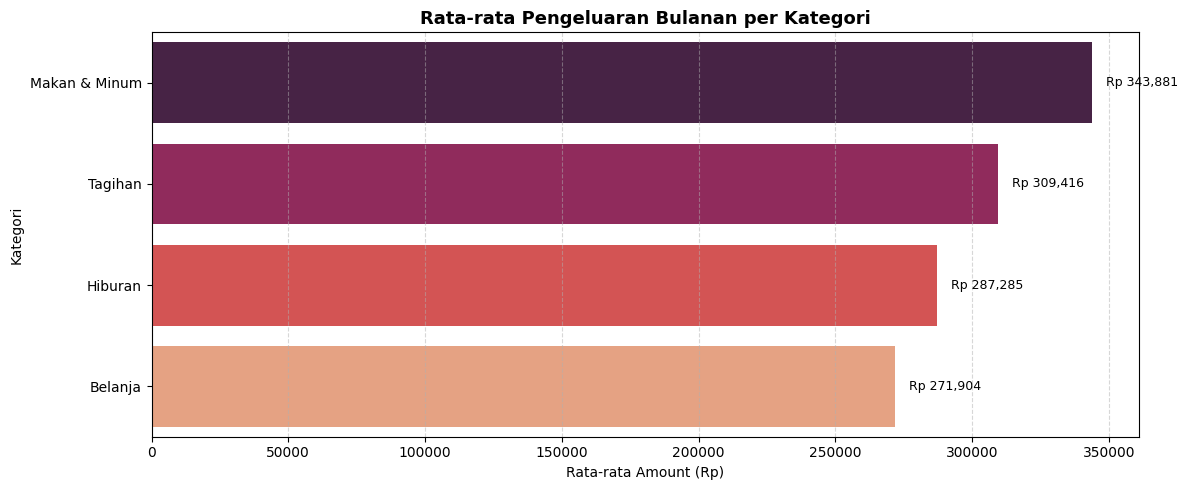

In [ ]:
monthly_exp_cat = expenses_df.groupby(['Year', 'Month', 'Category'])['Amount'].sum().reset_index()
avg_monthly_cat = monthly_exp_cat.groupby('Category')['Amount'].mean().sort_values(ascending=False)
expense_prop = expense_by_cat / expense_by_cat.sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=avg_monthly_cat.values, y=avg_monthly_cat.index,
            palette='rocket', hue=avg_monthly_cat.index, legend=False)
plt.title('Rata-rata Pengeluaran Bulanan per Kategori', fontsize=13, fontweight='bold')
plt.xlabel('Rata-rata Amount (Rp)')
plt.ylabel('Kategori')
for i, val in enumerate(avg_monthly_cat.values):
    plt.text(val + 5000, i, f'Rp {val:,.0f}', va='center', fontsize=9)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight**

Kategori makan dan minum menyumbang proporsi terbesar yaitu sebanyak 28,4% dari total pengeluaran. Dengan rata-rata bulanan yang dihabiskan sebesar Rp343,881.33.
Rekomendasi yang dapat diberikan adalah mengoptimalkan stok bahan pokok mandiri seperti telur dan beras atau melakukan mealprep guna mencegah pengeluaran impulsif di luar rumah.

**Rekomendasi**

Pengguna dapat menetapkan anggaran khusus (budgeting) untuk kategori Makan & Minum serta melakukan pemantauan rutin terhadap realisasi pengeluaran kategori tersebut. Strategi seperti membawa bekal, melakukan meal preparation, atau membatasi frekuensi pembelian makanan di luar rumah dapat membantu mengurangi pengeluaran tanpa mengganggu kebutuhan utama. Karena kategori ini merupakan penyumbang terbesar pengeluaran, penghematan kecil yang dilakukan secara konsisten berpotensi memberikan dampak signifikan terhadap kondisi keuangan secara keseluruhan.

## Question 3

**"Berapa persen perbedaan rata-rata pengeluaran antara weekday dan weekend selama Juli–Desember 2025?"**


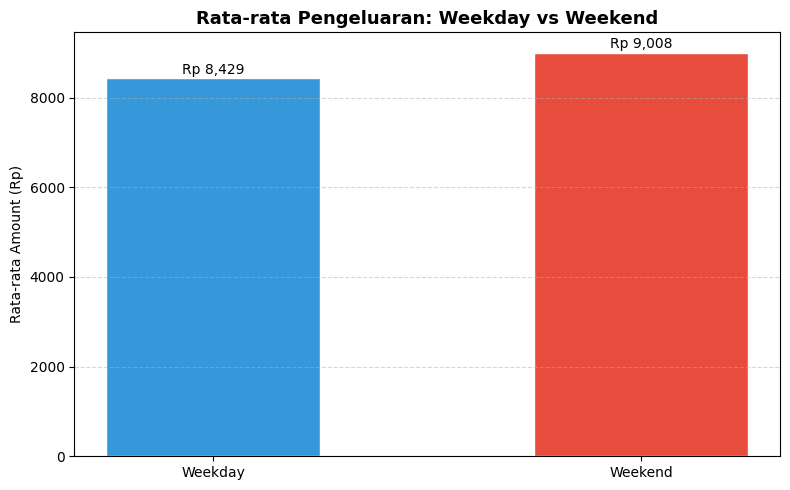

In [ ]:
# Weekday vs Weekend
exp_copy = expenses_df.copy()
exp_copy['DayOfWeek'] = exp_copy['Date'].dt.dayofweek
exp_copy['IsWeekend'] = exp_copy['DayOfWeek'].isin([5, 6])

wkd_avg = exp_copy.groupby('IsWeekend')['Amount'].mean()
wkd_avg.index = wkd_avg.index.map({False: 'Weekday', True: 'Weekend'})

plt.figure(figsize=(8, 5))
bars = plt.bar(wkd_avg.index, wkd_avg.values,
               color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
plt.title('Rata-rata Pengeluaran: Weekday vs Weekend', fontsize=13, fontweight='bold')
plt.ylabel('Rata-rata Amount (Rp)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, wkd_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100, f'Rp {val:,.0f}',
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

selisih    = wkd_avg['Weekend'] - wkd_avg['Weekday']
selisih_pct = (selisih / wkd_avg['Weekday']) * 100

**Insight**

Rata-rata pengeluaran pada akhir pekan (Weekend) terbukti lebih tinggi dibandingkan hari kerja (Weekday). Pola ini mengindikasikan adanya pengeluaran rekreasional dan konsumtif yang cenderung meningkat saat libur, seperti makan di luar, hiburan, dan belanja. Selisih persentase yang signifikan menunjukkan bahwa akhir pekan menjadi titik rawan kebocoran anggaran.

**Rekomendasi:** Tetapkan *weekend budget* khusus di awal setiap minggu, misalnya maksimal Rp200.000/hari untuk pengeluaran non-esensial di Sabtu dan Minggu.


## Question 4

**"Berapa selisih antara pemasukan tertinggi dan terendah per bulan selama Juli–Desember 2025, dan pada bulan mana pemasukan paling rendah?"**


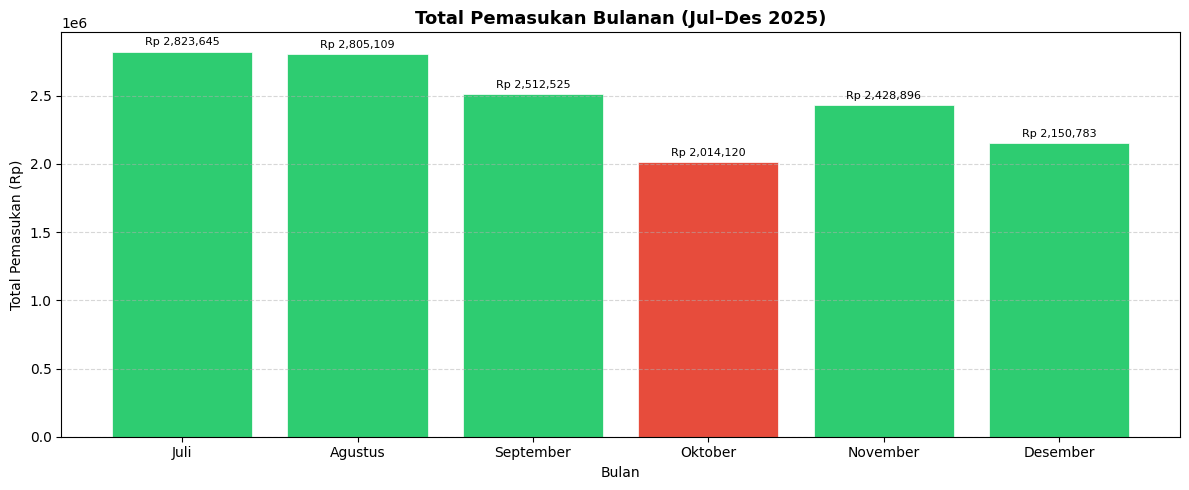

Pemasukan tertinggi : Juli 2025  — Rp 2,823,645.00
Pemasukan terendah  : Oktober 2025  — Rp 2,014,120.00
Selisih             : Rp 809,525.00


In [ ]:
monthly_income2 = income_df.groupby(['Year', 'Month'])['Amount'].sum().reset_index()
monthly_income2['Label'] = monthly_income2['Month'].map(month_names)

# Visualisasi
plt.figure(figsize=(12, 5))
colors_bar = ['#e74c3c' if v == monthly_income2['Amount'].min() else '#2ecc71'
              for v in monthly_income2['Amount']]
bars = plt.bar(monthly_income2['Label'], monthly_income2['Amount'],
               color=colors_bar, edgecolor='white', linewidth=0.5)
plt.title('Total Pemasukan Bulanan (Jul–Des 2025)', fontsize=13, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Total Pemasukan (Rp)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, monthly_income2['Amount']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30000,
             f'Rp {val:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

max_inc = monthly_income2.loc[monthly_income2['Amount'].idxmax()]
min_inc = monthly_income2.loc[monthly_income2['Amount'].idxmin()]
selisih = max_inc['Amount'] - min_inc['Amount']

print(f"Pemasukan tertinggi : {max_inc['Label']} 2025  — Rp {max_inc['Amount']:,.2f}")
print(f"Pemasukan terendah  : {min_inc['Label']} 2025  — Rp {min_inc['Amount']:,.2f}")
print(f"Selisih             : Rp {selisih:,.2f}")


**Insight**

Terdapat variasi pemasukan bulanan yang cukup terlihat antara bulan tertinggi dan terendah selama periode Juli–Desember 2025. Bulan dengan pemasukan terendah yaitu Oktober perlu diwaspadai karena secara langsung mempersempit ruang alokasi untuk tabungan dan investasi, serta meningkatkan risiko pengeluaran melebihi pemasukan.

**Rekomendasi:** Siapkan *income buffer* — ketika pemasukan di bulan-bulan tinggi, sisihkan selisihnya sebagai cadangan untuk menutup kebutuhan di bulan-bulan pemasukan rendah. Dengan begitu, pola pengeluaran bisa tetap konsisten meski pemasukan berfluktuasi.


## Question 5

**"Metode pembayaran (Account) apa yang paling sering digunakan untuk transaksi pengeluaran selama Juli–Desember 2025, dan berapa rata-rata nilai transaksinya per metode?"**


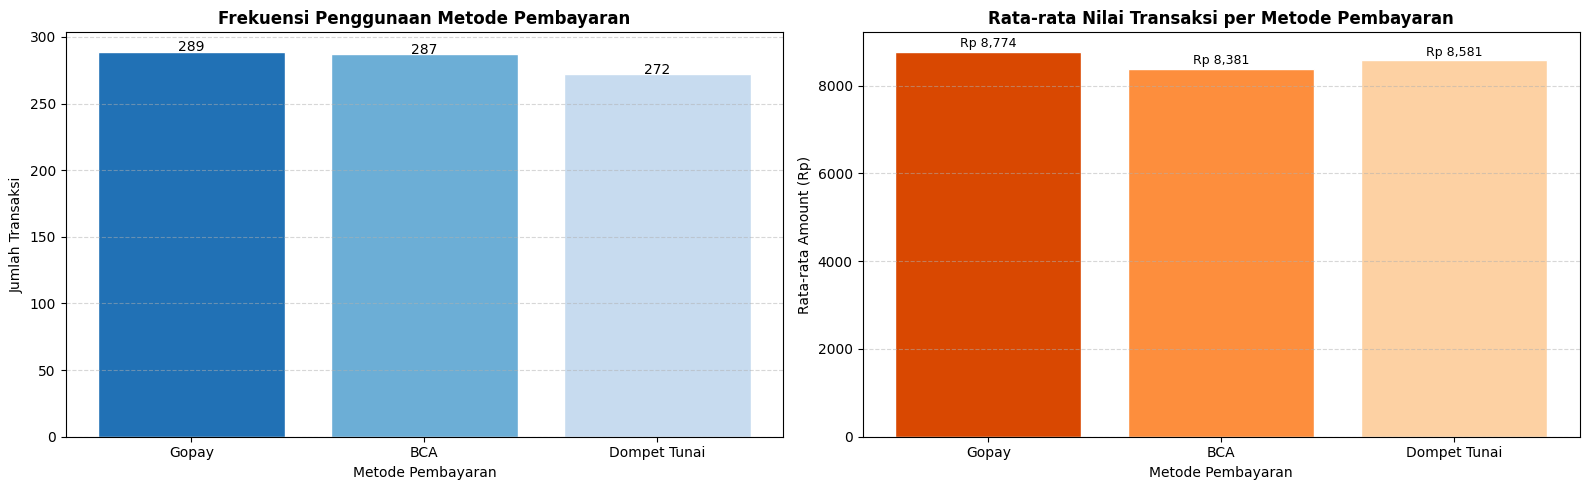

In [ ]:
# Frekuensi dan rata-rata per metode pembayaran
payment_freq = expenses_df.groupby('Account')['Amount'].agg(
    Frekuensi='count',
    Total='sum',
    Rata_rata='mean'
).sort_values('Frekuensi', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart kiri — frekuensi penggunaan
colors_freq = sns.color_palette('Blues_r', len(payment_freq))
axes[0].bar(payment_freq['Account'], payment_freq['Frekuensi'],
            color=colors_freq, edgecolor='white')
axes[0].set_title('Frekuensi Penggunaan Metode Pembayaran', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Metode Pembayaran')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(axes[0].patches, payment_freq['Frekuensi']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, str(val),
                 ha='center', fontsize=10)

# Bar chart kanan — rata-rata nilai transaksi
colors_avg = sns.color_palette('Oranges_r', len(payment_freq))
axes[1].bar(payment_freq['Account'], payment_freq['Rata_rata'],
            color=colors_avg, edgecolor='white')
axes[1].set_title('Rata-rata Nilai Transaksi per Metode Pembayaran', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Metode Pembayaran')
axes[1].set_ylabel('Rata-rata Amount (Rp)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(axes[1].patches, payment_freq['Rata_rata']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100, f'Rp {val:,.0f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Insight**

Penggunaan instrumen non-tunai, khususnya dompet digital, menjadi pilihan utama dan paling aktif digunakan untuk memfasilitasi transaksi harian. Dominasi pembayaran digital ini berpotensi menurunkan tingkat kesadaran pengeluaran dibanding metode tunai biasa, sehingga memperbesar risiko konsumsi impulsif secara tidak disadari.

**Rekomendasi:** Aktifkan notifikasi transaksi real-time pada metode pembayaran yang paling sering digunakan. Jika metode dominan adalah e-wallet, pertimbangkan untuk menetapkan batas top-up bulanan agar pengeluaran via metode tersebut tetap terkontrol.


## Question 6

**"Pada hari apa dalam seminggu total pengeluaran paling tinggi selama Juli–Desember 2025, dan berapa selisihnya dengan hari pengeluaran terendah?"**


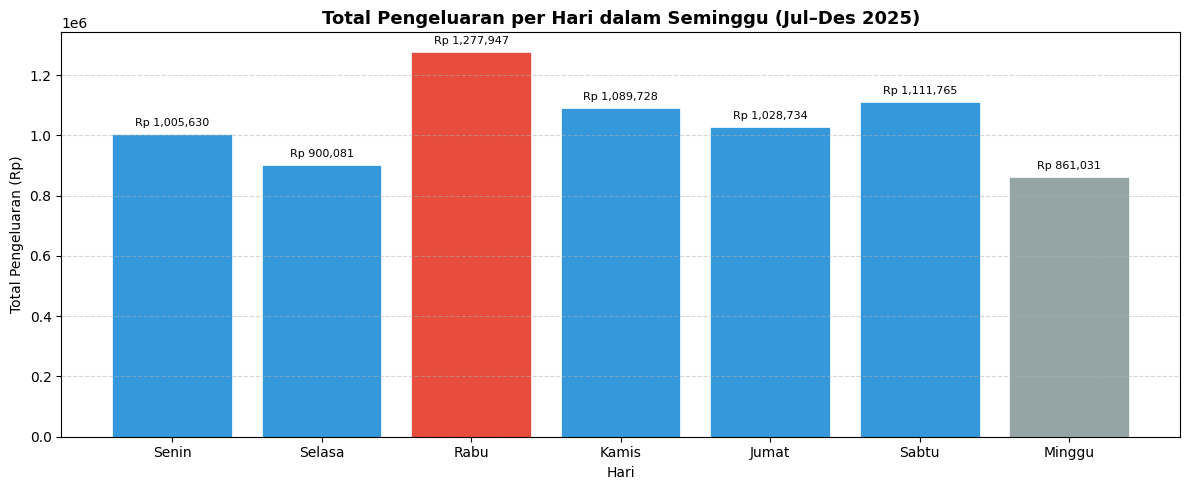

Selisih                    : Rp 809,525.00


In [ ]:
# Total pengeluaran per hari dalam seminggu
day_names = {0:'Senin', 1:'Selasa', 2:'Rabu', 3:'Kamis', 4:'Jumat', 5:'Sabtu', 6:'Minggu'}

exp_day = expenses_df.copy()
exp_day['DayOfWeek'] = exp_day['Date'].dt.dayofweek
exp_day['DayName']   = exp_day['DayOfWeek'].map(day_names)

daily_total = exp_day.groupby(['DayOfWeek', 'DayName'])['Amount'].sum().reset_index()
daily_total = daily_total.sort_values('DayOfWeek')

# Visualisasi
plt.figure(figsize=(12, 5))
colors_day = ['#e74c3c' if v == daily_total['Amount'].max()
              else '#95a5a6' if v == daily_total['Amount'].min()
              else '#3498db'
              for v in daily_total['Amount']]
bars = plt.bar(daily_total['DayName'], daily_total['Amount'],
               color=colors_day, edgecolor='white', linewidth=0.5)
plt.title('Total Pengeluaran per Hari dalam Seminggu (Jul–Des 2025)',
          fontsize=13, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Total Pengeluaran (Rp)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar, val in zip(bars, daily_total['Amount']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20000,
             f'Rp {val:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()
print(f"Selisih                    : Rp {selisih:,.2f}")


**Insight**

Pola belanja mingguan menunjukkan ritme yang tidak merata dengan lonjakan pengeluaran utama terpusat di pertengahan minggu pada hari Rabu, disusul oleh akhir pekan pada hari Sabtu. Sebaliknya, konsumsi paling minim terjadi pada hari Minggu, yang mengindikasikan adanya penumpukan transaksi rutin, belanja berkala, atau aktivitas sosial pada hari-hari produktif tersebut.

**Rekomendasi:** Jadikan hari dengan pengeluaran tertinggi sebagai "review day" mingguan — evaluasi pengeluaran di hari tersebut dan pertimbangkan untuk menggeser beberapa pembelian ke hari-hari dengan pengeluaran lebih rendah. Hal ini dapat membantu meratakan beban pengeluaran dan menghindari lonjakan kas di hari-hari tertentu.



# Feature Engineering
---

## Data Dictionary

### Kolom Asli Dataset

| Kolom | Tipe Data | Deskripsi | Contoh Nilai |
|---|---|---|---|
| `Date` | datetime | Tanggal transaksi | 2025-07-01 |
| `Title` | string | Nama/deskripsi transaksi | "Makan Siang", "Gaji Bulanan" |
| `Amount` | float | Nilai nominal transaksi dalam Rupiah | 45000.0 |
| `Type` | string | Jenis transaksi: pemasukan atau pengeluaran | INCOME, EXPENSE |
| `Category` | string | Kategori transaksi | Makan & Minum, Gaji, Belanja |
| `Account` | string | Metode/akun pembayaran yang digunakan | GoPay, BCA, Cash |

---

### Kolom Hasil Feature Engineering

| Fitur Baru | Tipe Data | Deskripsi | Alasan Dibuat |
|---|---|---|---|
| `DayOfWeek` | int (0–6) | Hari dalam seminggu (0=Senin, 6=Minggu) | EDA Q3 membuktikan pola pengeluaran berbeda antar hari; fitur temporal penting untuk model berbasis waktu seperti LSTM |
| `IsWeekend` | int (0/1) | 1 jika Sabtu/Minggu, 0 jika hari kerja | Menyederhanakan `DayOfWeek` menjadi sinyal biner weekday vs weekend yang terbukti signifikan di Q3 |
| `Is_Income` | int (0/1) | 1 jika transaksi pemasukan, 0 jika pengeluaran | Mengubah kolom `Type` (kategorikal) menjadi fitur biner yang lebih efisien sebagai target klasifikasi model |
| `Amount_Log` | float | Transformasi log: `log1p(Amount)` | Data `Amount` sangat skewed karena ada gaji besar vs pengeluaran harian kecil; log transform menormalkan distribusi tanpa harus menghapus outlier yang valid |
| `Category_Encoded` | int | Encoding numerik kolom `Category` | Model ML tidak dapat memproses string; encoding diperlukan agar kategori bisa dijadikan fitur input model |
| `Account_Encoded` | int | Encoding numerik kolom `Account` | Sama seperti `Category_Encoded` — metode pembayaran berpotensi menjadi sinyal pola perilaku keuangan |

> **Catatan:** `Month_Name` tidak dimasukkan sebagai fitur model karena bersifat label teks untuk keterbacaan manusia. Informasi bulan sudah terwakili oleh kolom `Month` (numerik) yang diekstrak saat EDA.


In [ ]:
# 1. Fitur waktu
df['DayOfWeek']  = df['Date'].dt.dayofweek
df['IsWeekend']  = df['DayOfWeek'].isin([5, 6]).astype(int)
df['Month_Name'] = df['Date'].dt.strftime('%B')

# 2. Is_Income
df['Is_Income'] = (df['Type'] == 'INCOME').astype(int)

# 3. Amount_Log — normalisasi tanpa hapus outlier
df['Amount_Log'] = np.log1p(df['Amount'])

print("Fitur waktu dan transformasi berhasil dibuat.")
print(df[['Date', 'DayOfWeek', 'IsWeekend', 'Month_Name', 'Is_Income',
          'Amount', 'Amount_Log']].head(8))


Fitur waktu dan transformasi berhasil dibuat.
        Date  DayOfWeek  IsWeekend Month_Name  Is_Income    Amount  Amount_Log
0 2025-07-01          1          0       July          0  15907.28    9.674595
1 2025-07-01          1          0       July          0  12793.08    9.456738
2 2025-07-01          1          0       July          0  13464.10    9.507856
3 2025-07-01          1          0       July          0  17475.95    9.768638
4 2025-07-02          2          0       July          0  11967.09    9.389999
5 2025-07-02          2          0       July          0  12037.66    9.395878
6 2025-07-02          2          0       July          0  12307.09    9.418012
7 2025-07-02          2          0       July          0  16031.74    9.682388


In [ ]:
# 4. Label Encoding
le_category = LabelEncoder()
le_account  = LabelEncoder()

df['Category_Encoded'] = le_category.fit_transform(df['Category'])
df['Account_Encoded']  = le_account.fit_transform(df['Account'])

print("Mapping Category → Encoded:")
for cls, enc in zip(le_category.classes_, range(len(le_category.classes_))):
    print(f"  {cls} → {enc}")

print("\nMapping Account → Encoded:")
for cls, enc in zip(le_account.classes_, range(len(le_account.classes_))):
    print(f"  {cls} → {enc}")


Mapping Category → Encoded:
  Belanja → 0
  Gaji → 1
  Goals → 2
  Hiburan → 3
  Makan & Minum → 4
  Tagihan → 5

Mapping Account → Encoded:
  BCA → 0
  Dompet Tunai → 1
  Gopay → 2


In [ ]:
# Ringkasan dataset final
print("DATASET FINAL SETELAH FEATURE ENGINEERING")
print(f"Shape  : {df.shape}")
print(f"Kolom  : {list(df.columns)}")
print()
df.head(10)


DATASET FINAL SETELAH FEATURE ENGINEERING
Shape  : (968, 16)
Kolom  : ['Date', 'Title', 'Amount', 'Type', 'Category', 'Account', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Month_Name', 'Is_Income', 'Amount_Log', 'Category_Encoded', 'Account_Encoded']



,Date,Title,Amount,Type,Category,Account,Year,Month,Day,DayOfWeek,IsWeekend,Month_Name,Is_Income,Amount_Log,Category_Encoded,Account_Encoded
0,2025-07-01,Parkir,15907.28,EXPENSE,Tagihan,Gopay,2025,7,1,1,0,July,0,9.674595,5,2
1,2025-07-01,Iuran Bulanan,12793.08,EXPENSE,Tagihan,BCA,2025,7,1,1,0,July,0,9.456738,5,0
2,2025-07-01,Streaming,13464.10,EXPENSE,Hiburan,Dompet Tunai,2025,7,1,1,0,July,0,9.507856,3,1
3,2025-07-01,Warung Nasi,17475.95,EXPENSE,Makan & Minum,Dompet Tunai,2025,7,1,1,0,July,0,9.768638,4,1
4,2025-07-02,Internet,11967.09,EXPENSE,Tagihan,Gopay,2025,7,2,2,0,July,0,9.389999,5,2
5,2025-07-02,Gofood,12037.66,EXPENSE,Makan & Minum,BCA,2025,7,2,2,0,July,0,9.395878,4,0
6,2025-07-02,Tissue,12307.09,EXPENSE,Belanja,BCA,2025,7,2,2,0,July,0,9.418012,0,0
7,2025-07-02,Alfamart,16031.74,EXPENSE,Belanja,Dompet Tunai,2025,7,2,2,0,July,0,9.682388,0,1
8,2025-07-02,Bioskop,8930.56,EXPENSE,Hiburan,Dompet Tunai,2025,7,2,2,0,July,0,9.097346,3,1
9,2025-07-02,Iuran Bulanan,1011.65,EXPENSE,Tagihan,BCA,2025,7,2,2,0,July,0,6.920326,5,0


In [ ]:
# Simpan dataset final
df.to_csv('Data_Finance_Final.csv', index=False)
print("Dataset final disimpan sebagai: Data_Finance_Final.csv")


Dataset final disimpan sebagai: Data_Finance_Final.csv
